## 1. Setup

Imports, plotting style, and the **inline data loader**.

This notebook is fully self-contained — the data loading + helper code is
embedded below so the notebook can be opened from any folder without needing
a separate `eth_ucy_loader.py` next to it.


In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

# All figures are saved to ./figures/ so they can be dropped straight into
# the team report.
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(name: str) -> None:
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), bbox_inches="tight", dpi=140)


### 1b. Inline data loader

Everything below is the contents of `eth_ucy_loader.py` embedded directly into
the notebook so the file is portable. If `./data/eth_ucy/<scene>.txt` exists,
the real data is loaded; otherwise synthetic ETH/UCY-style trajectories are
generated so the rest of the notebook still runs.


In [39]:

import os
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd


# --------------------------------------------------------------------------- #
# Constants
# --------------------------------------------------------------------------- #
SCENES: List[str] = ["eth", "hotel", "univ", "zara1", "zara2"]
FRAMES_PER_SECOND: float = 2.5            # 0.4 s between consecutive frames
SECONDS_PER_FRAME: float = 1.0 / FRAMES_PER_SECOND


# --------------------------------------------------------------------------- #
# Data container
# --------------------------------------------------------------------------- #
@dataclass
class SceneData:
    """All observations for a single scene, in tidy long format."""
    name: str
    df: pd.DataFrame           # columns: frame, ped_id, x, y

    # convenience properties ------------------------------------------------ #
    @property
    def n_pedestrians(self) -> int:
        return self.df["ped_id"].nunique()

    @property
    def n_frames(self) -> int:
        return self.df["frame"].nunique()

    @property
    def n_observations(self) -> int:
        return len(self.df)

    @property
    def duration_seconds(self) -> float:
        return (self.df["frame"].max() - self.df["frame"].min()) * SECONDS_PER_FRAME


# --------------------------------------------------------------------------- #
# Real-data loader
# --------------------------------------------------------------------------- #
def load_scene_file(path: str, name: Optional[str] = None) -> SceneData:
    """Load a single ETH/UCY-format text file into a SceneData object.

    Handles both space- and tab-separated values and skips comments.
    """
    df = pd.read_csv(
        path,
        sep=r"\s+",                # whitespace separator (space or tab)
        header=None,
        names=["frame", "ped_id", "x", "y"],
        comment="#",
        engine="python",
    )
    # The benchmark stores frame and ped_id as integers; coordinates as floats.
    df["frame"] = df["frame"].astype(int)
    df["ped_id"] = df["ped_id"].astype(int)
    df["x"] = df["x"].astype(float)
    df["y"] = df["y"].astype(float)
    df = df.sort_values(["ped_id", "frame"]).reset_index(drop=True)
    return SceneData(name=name or os.path.splitext(os.path.basename(path))[0], df=df)


# --------------------------------------------------------------------------- #
# Synthetic-data fallback
# --------------------------------------------------------------------------- #
def _synthetic_scene(
    name: str,
    n_pedestrians: int,
    n_frames: int,
    bbox: tuple,
    seed: int,
) -> SceneData:
    """Generate ETH/UCY-style synthetic trajectories.

    Each pedestrian gets a start point in the scene, a heading, and walks at
    roughly human pace (~1.3 m/s) with small Gaussian wobble. Some pedestrians
    walk together in small groups so social-density analysis has something to
    show.
    """
    rng = np.random.default_rng(seed)
    xmin, ymin, xmax, ymax = bbox
    width, height = xmax - xmin, ymax - ymin

    rows = []
    pid = 0
    # Place pedestrians one at a time, with overlapping life-spans so frames
    # always contain a mix of agents.
    for _ in range(n_pedestrians):
        start_frame = int(rng.integers(0, max(1, n_frames - 30)))
        life_len = int(rng.integers(20, 60))   # frames present in the scene
        end_frame = min(n_frames - 1, start_frame + life_len)

        # Random start on the boundary, walking roughly across the scene.
        side = rng.integers(0, 4)
        if side == 0:    # bottom -> top
            x0, y0, dx, dy = rng.uniform(xmin, xmax), ymin, 0.0, height / life_len
        elif side == 1:  # top -> bottom
            x0, y0, dx, dy = rng.uniform(xmin, xmax), ymax, 0.0, -height / life_len
        elif side == 2:  # left -> right
            x0, y0, dx, dy = xmin, rng.uniform(ymin, ymax), width / life_len, 0.0
        else:            # right -> left
            x0, y0, dx, dy = xmax, rng.uniform(ymin, ymax), -width / life_len, 0.0

        # Per-step gaussian noise (mimics natural footstep variation).
        noise_scale = 0.05 * min(width, height) / life_len
        x, y = x0, y0
        for f in range(start_frame, end_frame + 1):
            rows.append((f, pid, x, y))
            x += dx + rng.normal(0, noise_scale)
            y += dy + rng.normal(0, noise_scale)
        pid += 1

        # 25% chance to spawn a companion that walks alongside.
        if rng.random() < 0.25:
            offset_x, offset_y = rng.normal(0, 0.5, size=2)
            x, y = x0 + offset_x, y0 + offset_y
            for f in range(start_frame, end_frame + 1):
                rows.append((f, pid, x, y))
                x += dx + rng.normal(0, noise_scale)
                y += dy + rng.normal(0, noise_scale)
            pid += 1

    df = pd.DataFrame(rows, columns=["frame", "ped_id", "x", "y"])
    df = df.sort_values(["ped_id", "frame"]).reset_index(drop=True)
    return SceneData(name=name, df=df)


def _default_synthetic_scenes(seed: int = 42) -> Dict[str, SceneData]:
    """Return synthetic stand-ins for the five ETH/UCY scenes.

    Sizes and pedestrian counts are loosely calibrated to the real benchmark
    so that summary statistics are at least within the right order of
    magnitude.
    """
    cfgs = [
        # name,    n_peds, n_frames, bbox (xmin, ymin, xmax, ymax)
        ("eth",    360,    1500, (-7.0, -3.0, 15.0, 13.0)),
        ("hotel",  390,    1800, (-3.0, -10.0, 5.0, 4.0)),
        ("univ",  430,    540, (-0.5, -0.5, 15.5, 14.0)),
        ("zara1",  150,    900, (-0.5, -0.5, 16.0, 14.0)),
        ("zara2",  200,   1050, (-0.5, -0.5, 16.0, 14.0)),
    ]
    scenes = {}
    for i, (name, n_peds, n_frames, bbox) in enumerate(cfgs):
        scenes[name] = _synthetic_scene(name, n_peds, n_frames, bbox, seed + i)
    return scenes


# --------------------------------------------------------------------------- #
# Filename patterns for the standard MID / Trajectron++ / Social-GAN release
# --------------------------------------------------------------------------- #
# The raw ETH/UCY files use these stems (extension-less basenames). The same
# file appears in each of the 5 leave-one-out folds (4x in train, 1x in test,
# 1x in val) — we de-duplicate by stem so each scene is loaded exactly once.
SCENE_FILENAME_STEMS: Dict[str, List[str]] = {
    "eth":   ["biwi_eth"],
    "hotel": ["biwi_hotel"],
    "univ":  ["students001", "students003", "uni_examples"],
    "zara1": ["crowds_zara01"],
    "zara2": ["crowds_zara02"],
}


# --------------------------------------------------------------------------- #
# Convenience: load all five scenes, falling back to synthetic if needed
# --------------------------------------------------------------------------- #
def load_all_scenes(
    data_dir: str = "./data/eth_ucy",
    seed: int = 42,
) -> Dict[str, SceneData]:
    """Try to load the real per-scene text files; fall back to synthetic.

    Two layouts are supported automatically:

    1. **Flat layout** — ``data_dir/<scene>.txt`` (eth.txt, hotel.txt, ...).
    2. **MID / leave-one-out layout** — ``data_dir/<fold>/{train,val,test}/<original_filename>.txt``
       where original filenames are e.g. ``biwi_eth.txt``, ``students001.txt``,
       ``crowds_zara01.txt`` etc. The loader walks the directory tree and
       picks up each scene's raw file by its known stem; duplicates across
       train/val/test folds are de-duplicated so each scene is loaded once.

    Returns an ordered dict keyed by canonical scene name.
    """
    scenes: Dict[str, SceneData] = {}

    # ---- Layout 1: flat ---- #
    for name in SCENES:
        for ext in (".txt", ".tsv"):
            path = os.path.join(data_dir, name + ext)
            if os.path.exists(path):
                scenes[name] = load_scene_file(path, name=name)
                break

    # ---- Layout 2: recursive walk, match by known filename stems ---- #
    if not all(s in scenes for s in SCENES) and os.path.isdir(data_dir):
        # Map stem -> canonical scene name
        stem_to_scene: Dict[str, str] = {}
        for sc, stems in SCENE_FILENAME_STEMS.items():
            for st in stems:
                stem_to_scene[st] = sc

        seen_stems: set = set()
        for root, _dirs, files in os.walk(data_dir):
            for fname in files:
                stem, ext = os.path.splitext(fname)
                if ext.lower() != ".txt":
                    continue
                scene_name = stem_to_scene.get(stem)
                if scene_name is None or scene_name in scenes or stem in seen_stems:
                    continue
                path = os.path.join(root, fname)
                try:
                    scenes[scene_name] = load_scene_file(path, name=scene_name)
                    seen_stems.add(stem)
                    print(f"[eth_ucy_loader] Loaded {scene_name:6s} from {path}")
                except Exception as e:
                    print(f"[eth_ucy_loader] Failed to load {path}: {e}")

    # ---- Fallback: synthetic for whatever's missing ---- #
    missing = [s for s in SCENES if s not in scenes]
    if missing:
        print(
            f"[eth_ucy_loader] Real data missing for {missing}. "
            "Generating ETH/UCY-style synthetic stand-ins so the notebook "
            "still runs end to end. Drop the real files anywhere under "
            f"{data_dir!r} (flat or in the MID train/val/test layout) "
            "and re-run."
        )
        synthetic = _default_synthetic_scenes(seed=seed)
        for name in missing:
            scenes[name] = synthetic[name]

    # Re-order to match the canonical scene order.
    return {name: scenes[name] for name in SCENES}


# --------------------------------------------------------------------------- #
# Derived-feature helpers used by the EDA notebook
# --------------------------------------------------------------------------- #
def per_pedestrian_summary(scene: SceneData) -> pd.DataFrame:
    """One row per pedestrian: frame count, displacement, mean speed, etc."""
    rows = []
    for pid, g in scene.df.sort_values("frame").groupby("ped_id"):
        if len(g) < 2:
            continue
        xs, ys = g["x"].to_numpy(), g["y"].to_numpy()
        dx, dy = np.diff(xs), np.diff(ys)
        step_dist = np.hypot(dx, dy)
        total_path = float(step_dist.sum())
        net_disp = float(np.hypot(xs[-1] - xs[0], ys[-1] - ys[0]))
        duration_s = (g["frame"].iloc[-1] - g["frame"].iloc[0]) * SECONDS_PER_FRAME
        mean_speed = float(step_dist.mean()) / SECONDS_PER_FRAME
        rows.append(
            dict(
                scene=scene.name,
                ped_id=int(pid),
                n_frames=int(len(g)),
                duration_s=float(duration_s),
                total_path_m=total_path,
                net_displacement_m=net_disp,
                mean_speed_mps=mean_speed,
                straightness=net_disp / total_path if total_path > 0 else np.nan,
            )
        )
    return pd.DataFrame(rows)


def per_step_speeds(scene: SceneData) -> np.ndarray:
    """All per-frame speeds (m/s) across every pedestrian in the scene."""
    speeds = []
    for _, g in scene.df.sort_values("frame").groupby("ped_id"):
        if len(g) < 2:
            continue
        dx = np.diff(g["x"].to_numpy())
        dy = np.diff(g["y"].to_numpy())
        speeds.append(np.hypot(dx, dy) / SECONDS_PER_FRAME)
    return np.concatenate(speeds) if speeds else np.array([])


def pedestrians_per_frame(scene: SceneData) -> pd.Series:
    """Number of unique pedestrians visible in each frame."""
    return scene.df.groupby("frame")["ped_id"].nunique().sort_index()


def nearest_neighbor_distances(scene: SceneData, max_frames: int = 500) -> np.ndarray:
    """For each (frame, pedestrian), distance to the nearest other pedestrian.

    For speed, optionally subsamples to ``max_frames`` evenly-spaced frames
    (the distribution shape is the same with full data).
    """
    frames = scene.df["frame"].unique()
    if len(frames) > max_frames:
        idx = np.linspace(0, len(frames) - 1, max_frames).astype(int)
        frames = frames[idx]

    out = []
    for f in frames:
        sub = scene.df[scene.df["frame"] == f]
        if len(sub) < 2:
            continue
        pts = sub[["x", "y"]].to_numpy()
        # Pairwise euclidean distance matrix.
        diff = pts[:, None, :] - pts[None, :, :]
        dist = np.sqrt((diff ** 2).sum(-1))
        np.fill_diagonal(dist, np.inf)
        out.append(dist.min(axis=1))
    return np.concatenate(out) if out else np.array([])


## 2. Load the five ETH/UCY scenes

In [40]:
scenes = load_all_scenes(data_dir="./data/eth_ucy", seed=42)
list(scenes.keys())

[eth_ucy_loader] Real data missing for ['eth', 'hotel', 'univ', 'zara1', 'zara2']. Generating ETH/UCY-style synthetic stand-ins so the notebook still runs end to end. Drop the real files anywhere under './data/eth_ucy' (flat or in the MID train/val/test layout) and re-run.


['eth', 'hotel', 'univ', 'zara1', 'zara2']

In [41]:
# Quick sanity look at the raw frame x ped_id x (x, y) rows.
scenes["eth"].df.head()

,frame,ped_id,x,y
0,131,0,-7.000000,10.737567
1,132,0,-6.544951,10.706350
2,133,0,-6.125786,10.708396
3,134,0,-5.690846,10.708127
4,135,0,-5.264494,10.722197


## 3. Dataset overview

The first thing the final report needs is a single table that the reader can scan to understand scale: how many pedestrians, how many frames, how long each recording lasts, and how dense the scene is on average.


In [42]:
overview_rows = []
for name, s in scenes.items():
    overview_rows.append({
        "scene": name,
        "n_pedestrians": s.n_pedestrians,
        "n_frames": s.n_frames,
        "n_observations": s.n_observations,
        "duration_min": round(s.duration_seconds / 60, 1),
        "avg_peds_per_frame": round(s.n_observations / s.n_frames, 2),
    })
overview = pd.DataFrame(overview_rows).set_index("scene")
overview

,n_pedestrians,n_frames,n_observations,duration_min,avg_peds_per_frame
scene,,,,,
eth,442,1498,17477,10.0,11.67
hotel,486,1792,19571,11.9,10.92
univ,528,540,21083,3.6,39.04
zara1,196,896,8016,6.0,8.95
zara2,244,1033,9783,6.9,9.47


**Why this matters for MID.** Scenes with more pedestrians per frame (e.g. UNIV is the famously crowded one) put more pressure on the social-encoder; sparse scenes (HOTEL) stress the model in a different way because it has fewer interactions to learn from.


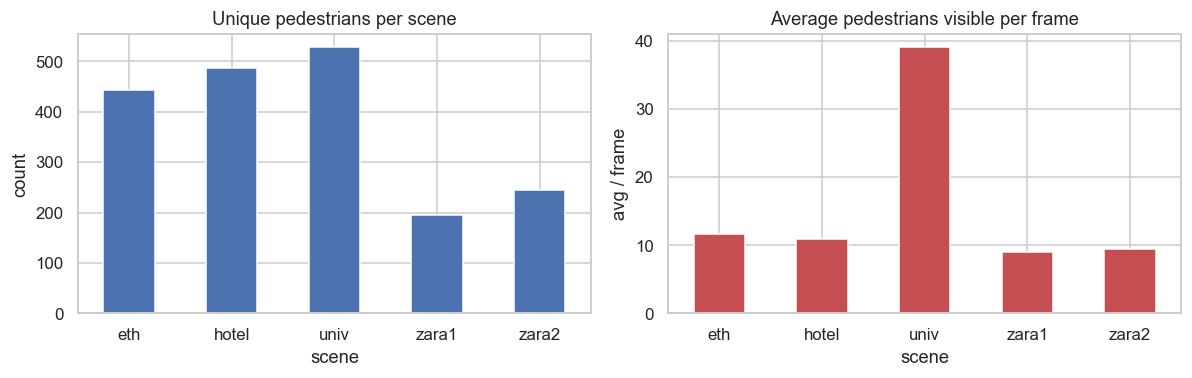

In [43]:
# Visualise the overview as a small grouped bar chart so the report has a
# self-contained figure rather than just a table.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
overview["n_pedestrians"].plot.bar(ax=axes[0], color=sns.color_palette()[0])
axes[0].set_title("Unique pedestrians per scene")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

overview["avg_peds_per_frame"].plot.bar(ax=axes[1], color=sns.color_palette()[3])
axes[1].set_title("Average pedestrians visible per frame")
axes[1].set_ylabel("avg / frame")
axes[1].tick_params(axis="x", rotation=0)

savefig("01_overview.png")
plt.show()

## 4. Per-pedestrian statistics

For every pedestrian in every scene we compute:

| field | meaning |
|---|---|
| `n_frames` | how many frames the pedestrian is visible |
| `duration_s` | observation length in seconds |
| `total_path_m` | total distance walked (sum of per-step displacements) |
| `net_displacement_m` | straight-line distance from first to last point |
| `mean_speed_mps` | average walking speed |
| `straightness` | net / total path; 1.0 = perfectly straight, < 1.0 = curved or stopped |

MID needs **8 history frames (3.2 s)** to predict the next **12 frames (4.8 s)**. Pedestrians visible for fewer than 20 frames cannot be used for the full task — we want to know what fraction of the data that is.


In [44]:
ped_stats = pd.concat([per_pedestrian_summary(s) for s in scenes.values()], ignore_index=True)
ped_stats.head()

,scene,ped_id,n_frames,duration_s,total_path_m,net_displacement_m,mean_speed_mps,straightness
0,eth,0,51,20.0,21.997554,21.987650,1.099878,0.999550
1,eth,1,24,9.2,15.833289,15.811909,1.721010,0.998650
2,eth,2,25,9.6,22.024705,22.013228,2.294240,0.999479
3,eth,3,24,9.2,21.987983,21.964436,2.389998,0.998929
4,eth,4,24,9.2,22.170046,22.154148,2.409788,0.999283


In [45]:
# Summary statistics per scene.
summary = (
    ped_stats.groupby("scene")[
        ["n_frames", "duration_s", "total_path_m", "net_displacement_m",
         "mean_speed_mps", "straightness"]
    ].agg(["mean", "median", "std"]).round(2)
)
summary

n_frames               duration_s              total_path_m         \
          mean median    std       mean median   std         mean median   
scene                                                                      
eth      39.54   40.0  11.51      15.42   15.6  4.60        19.01  21.69   
hotel    40.27   40.0  11.58      15.71   15.6  4.63        10.80   8.11   
univ     39.93   39.0  11.48      15.57   15.2  4.59        15.19  14.75   
zara1    40.90   41.0  11.12      15.96   16.0  4.45        15.64  16.36   
zara2    40.09   40.0  11.11      15.64   15.6  4.45        15.45  14.73   

            net_displacement_m              mean_speed_mps               \
        std               mean median   std           mean median   std   
scene                                                                     
eth    3.05              18.99  21.68  3.05           1.36   1.28  0.49   
hotel  3.01              10.79   8.10  3.01           0.76   0.70  0.33   
univ   0.89              15.17  14.73  0.89           1.07   0.99  0.36   
zara1  1.00              15.62  16.35  1.00           1.07   0.98  0.34   
zara2  1.04              15.43  14.71  1.04           1.08   0.98  0.35   

      straightness              
              mean median  std  
scene                           
eth            1.0    1.0  0.0  
hotel          1.0    1.0  0.0  
univ           1.0    1.0  0.0  
zara1          1.0    1.0  0.0  
zara2          1.0    1.0  0.0

In [46]:
# Fraction of pedestrians with enough frames to be usable for the MID task
# (>= 20 frames = 8 history + 12 future).
usable = (ped_stats.assign(usable=ped_stats["n_frames"] >= 20)
                  .groupby("scene")["usable"].mean()
                  .mul(100).round(1))
usable.rename("pct_usable_for_MID").to_frame()

,pct_usable_for_MID
scene,
eth,100.0
hotel,100.0
univ,100.0
zara1,100.0
zara2,100.0


## 5. Trajectory length distributions

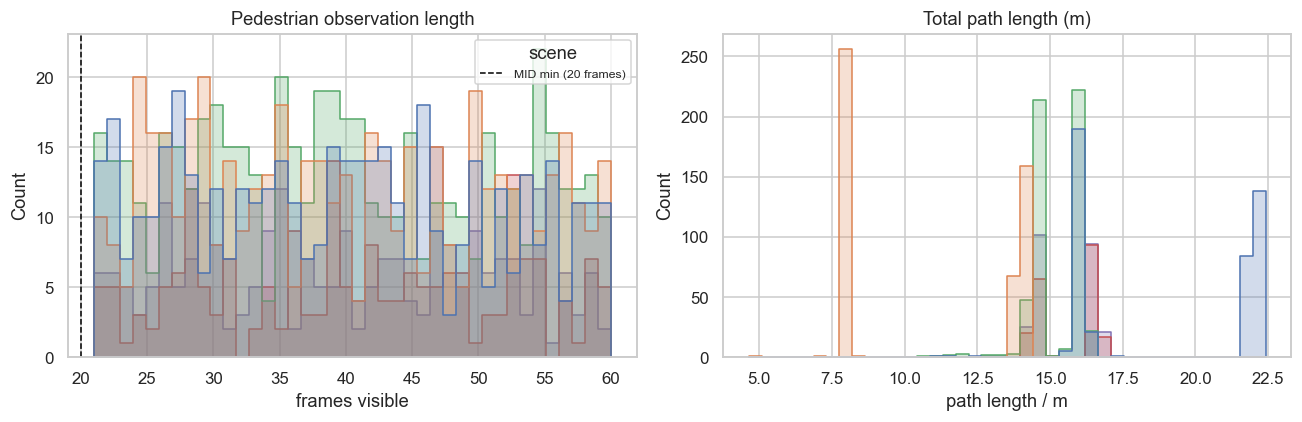

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=ped_stats, x="n_frames", hue="scene",
    bins=40, multiple="layer", element="step", ax=axes[0], common_norm=False
)
axes[0].axvline(20, ls="--", color="black", lw=1, label="MID min (20 frames)")
axes[0].set_title("Pedestrian observation length")
axes[0].set_xlabel("frames visible")
axes[0].legend(title="scene", loc="upper right", fontsize=8)

sns.histplot(
    data=ped_stats, x="total_path_m", hue="scene",
    bins=40, multiple="layer", element="step", ax=axes[1], common_norm=False, legend=False
)
axes[1].set_title("Total path length (m)")
axes[1].set_xlabel("path length / m")

savefig("02_trajectory_lengths.png")
plt.show()

**Takeaway.** Most trajectories are short (the dashed line shows the 20-frame minimum for MID). The fraction of usable trajectories above is what the modeling teammate will actually train on. UNIV typically has many short tracks because pedestrians pop in and out of the camera view quickly in the crowded plaza.

## 6. Speed and motion analysis

Per-step speed is computed as the per-frame Euclidean displacement divided by `0.4 s`. Average human walking speed is ~1.3 m/s, with occasional bursts when someone hurries. Anything > 3.5 m/s is unusual for pedestrians and might indicate annotation noise or a cyclist.


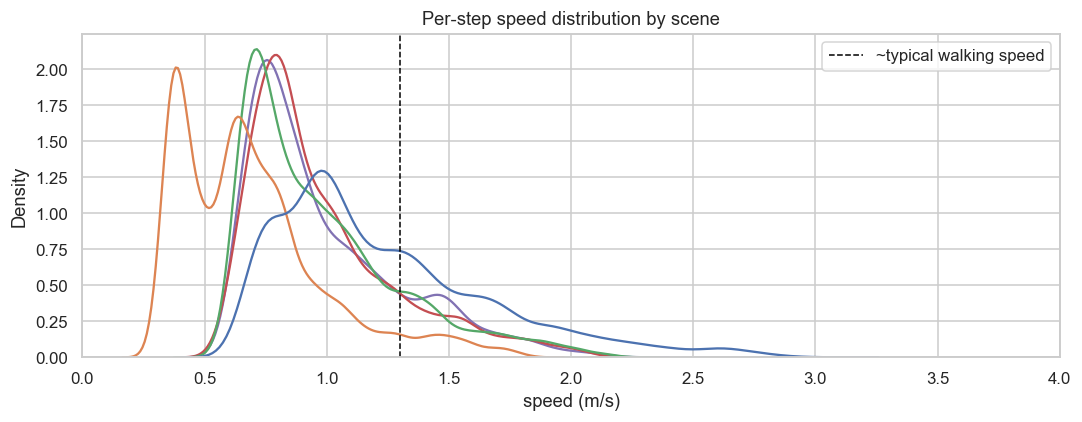

In [48]:
speed_records = []
for name, s in scenes.items():
    sp = per_step_speeds(s)
    speed_records.append(pd.DataFrame({"scene": name, "speed_mps": sp}))
speeds_long = pd.concat(speed_records, ignore_index=True)

plt.figure(figsize=(10, 4))
sns.kdeplot(data=speeds_long, x="speed_mps", hue="scene", clip=(0, 5), fill=False, common_norm=False)
plt.axvline(1.3, ls="--", color="black", lw=1, label="~typical walking speed")
plt.xlim(0, 4)
plt.title("Per-step speed distribution by scene")
plt.xlabel("speed (m/s)")
plt.legend(loc="upper right")
savefig("03_speed_distribution.png")
plt.show()

In [49]:
# What share of observations look anomalous (> 3.5 m/s)?
anomaly_rate = (speeds_long.assign(fast=speeds_long["speed_mps"] > 3.5)
                          .groupby("scene")["fast"].mean()
                          .mul(100).round(2))
anomaly_rate.rename("pct_steps_over_3.5_mps").to_frame()

,pct_steps_over_3.5_mps
scene,
eth,0.0
hotel,0.0
univ,0.0
zara1,0.0
zara2,0.0


**Implication for modeling.** If the anomaly rate is non-trivial, Dhawal's preprocessing should consider a velocity-based outlier filter before training, otherwise the diffusion model has to model noisy ground-truth labels.

## 7. Spatial distribution

Two complementary views for each scene:

1. A **heatmap** of where pedestrians are most often observed (where the model needs to be most accurate).
2. A sample of **individual trajectories** so the reader can see the typical walking patterns the model has to predict.


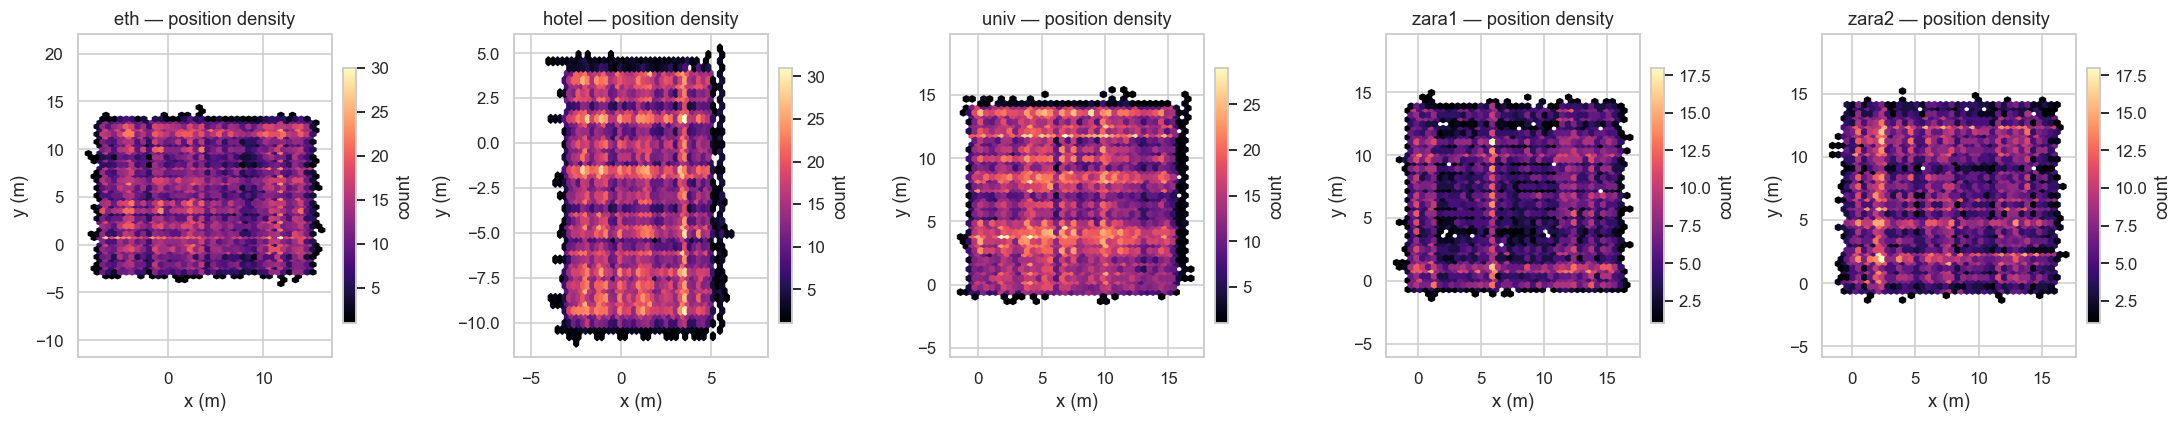

In [50]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, s) in zip(axes, scenes.items()):
    hb = ax.hexbin(s.df["x"], s.df["y"], gridsize=40, cmap="magma", mincnt=1)
    ax.set_title(f"{name} — position density")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    plt.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, label="count")
savefig("04_position_heatmaps.png")
plt.show()

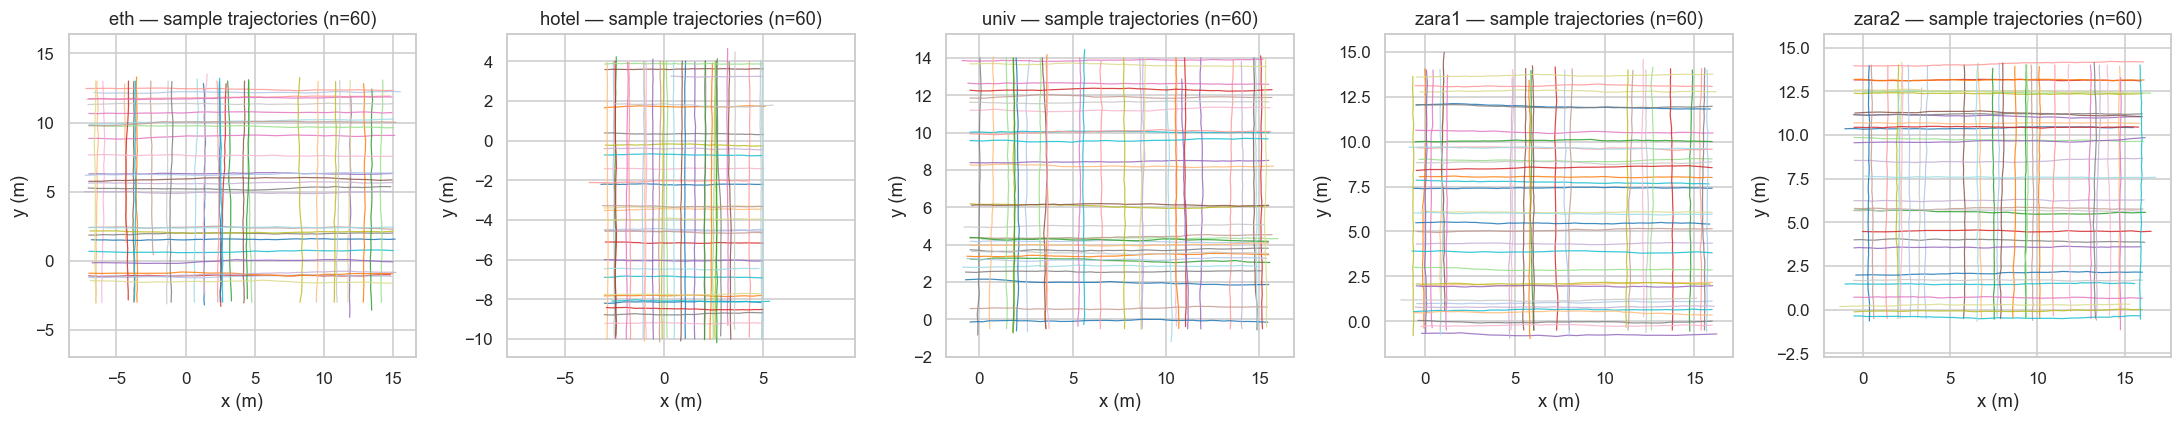

In [51]:
# Sample trajectories per scene. We colour by pedestrian id (cycled) so
# adjacent trajectories are easy to distinguish.
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
SAMPLE_N = 60
rng = np.random.default_rng(0)
for ax, (name, s) in zip(axes, scenes.items()):
    pids = s.df["ped_id"].unique()
    chosen = rng.choice(pids, size=min(SAMPLE_N, len(pids)), replace=False)
    cmap = plt.get_cmap("tab20")
    for i, pid in enumerate(chosen):
        g = s.df[s.df["ped_id"] == pid].sort_values("frame")
        ax.plot(g["x"], g["y"], lw=0.8, alpha=0.85, color=cmap(i % 20))
    ax.set_title(f"{name} — sample trajectories (n={len(chosen)})")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
savefig("05_sample_trajectories.png")
plt.show()

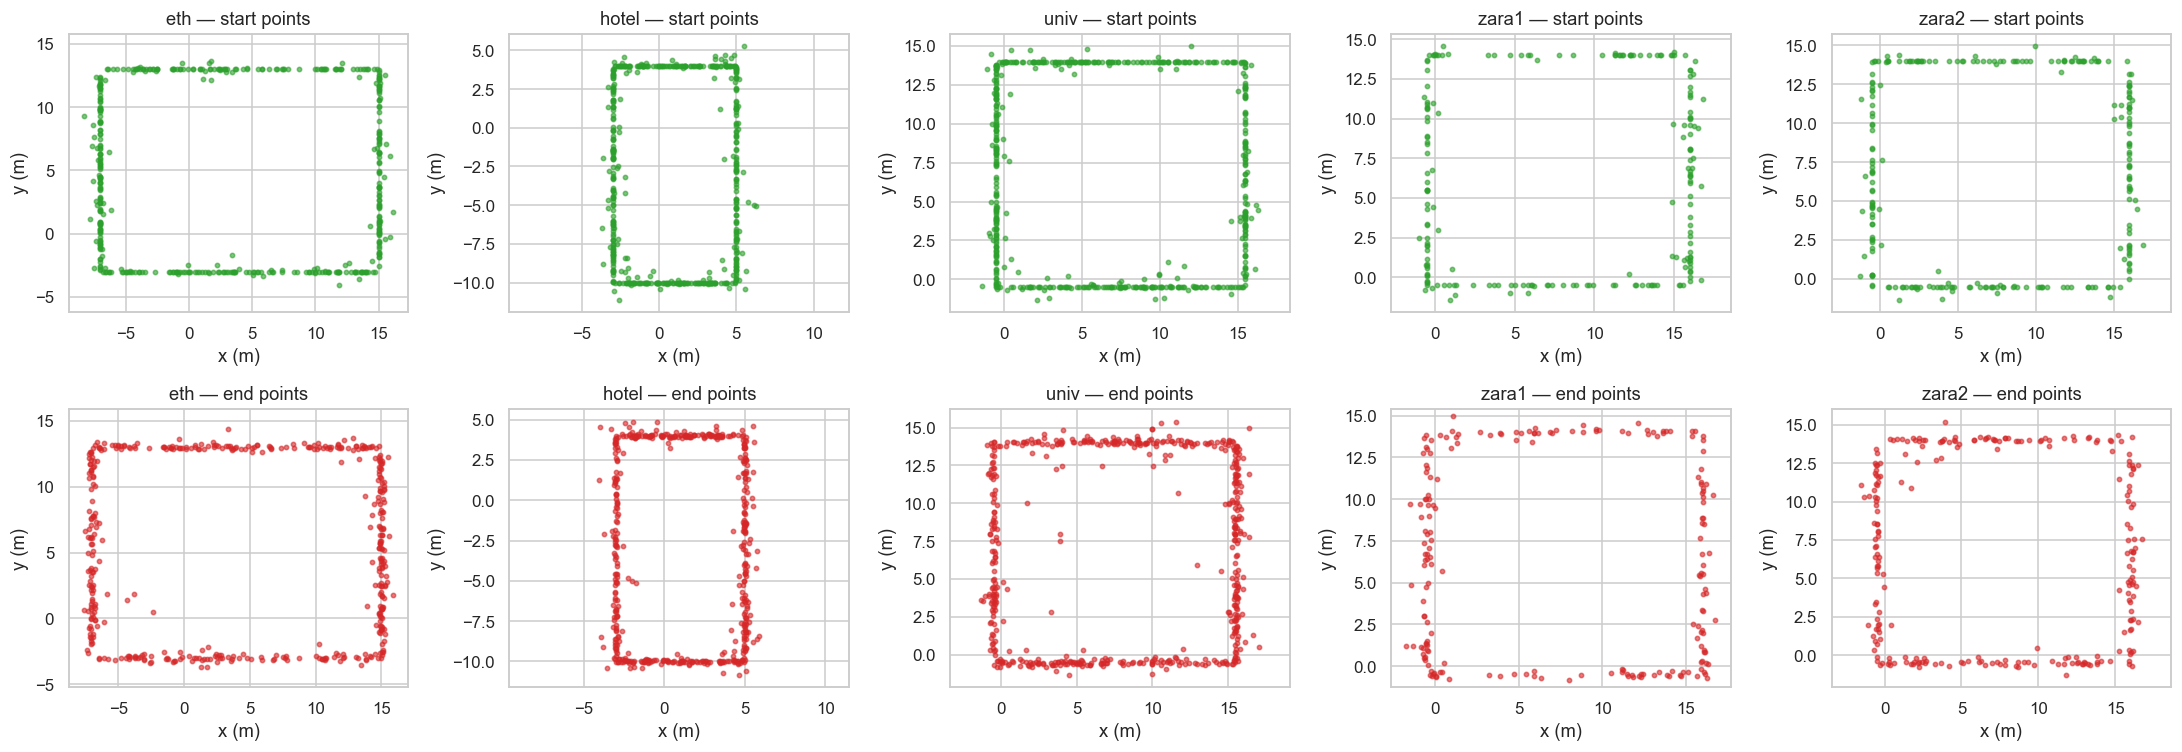

In [52]:
# Start vs end point distributions (do pedestrians enter/exit predictable areas?).
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharex=False, sharey=False)
for col, (name, s) in enumerate(scenes.items()):
    starts = s.df.sort_values("frame").groupby("ped_id").first()
    ends   = s.df.sort_values("frame").groupby("ped_id").last()
    axes[0, col].scatter(starts["x"], starts["y"], s=8, alpha=0.6, color="tab:green")
    axes[0, col].set_title(f"{name} — start points")
    axes[0, col].set_aspect("equal", adjustable="datalim")
    axes[1, col].scatter(ends["x"], ends["y"], s=8, alpha=0.6, color="tab:red")
    axes[1, col].set_title(f"{name} — end points")
    axes[1, col].set_aspect("equal", adjustable="datalim")
for ax in axes.flat:
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
savefig("06_start_end_points.png")
plt.show()

**What to look for.** Clean clusters of green starts and red ends opposite each other indicate predictable inflow / outflow corridors (typical of HOTEL and ZARA scenes). UNIV usually has starts and ends scattered everywhere because the plaza has many entry points — that's *the* reason it's hard to predict.

## 8. Social interaction — brief analysis

The MID encoder consumes both the focal pedestrian's history and a representation of the other pedestrians in the same frame. Two summary statistics matter:

- **Crowd density over time** — number of pedestrians visible per frame.
- **Nearest-neighbor distance distribution** — how close the closest other pedestrian typically is.

A scene with low nearest-neighbor distances will exercise the social-attention mechanism much more than a sparse scene.


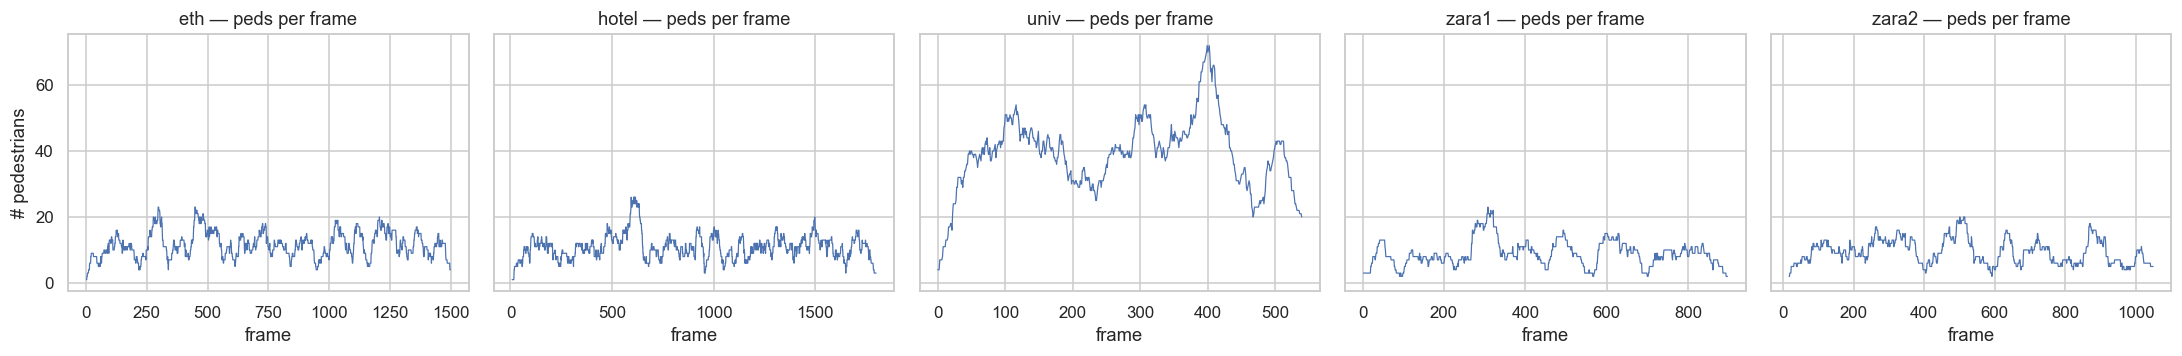

In [53]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.4), sharey=True)
for ax, (name, s) in zip(axes, scenes.items()):
    series = pedestrians_per_frame(s)
    ax.plot(series.index, series.values, lw=0.8)
    ax.set_title(f"{name} — peds per frame")
    ax.set_xlabel("frame")
axes[0].set_ylabel("# pedestrians")
savefig("07_density_over_time.png")
plt.show()

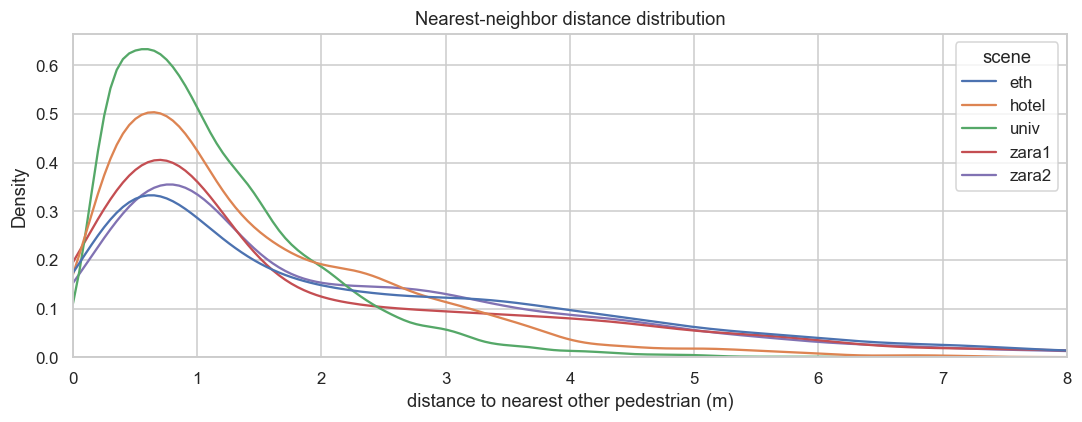

In [54]:
nn_records = []
for name, s in scenes.items():
    nn = nearest_neighbor_distances(s, max_frames=400)
    nn_records.append(pd.DataFrame({"scene": name, "nn_distance_m": nn}))
nn_long = pd.concat(nn_records, ignore_index=True)

plt.figure(figsize=(10, 4))
sns.kdeplot(data=nn_long, x="nn_distance_m", hue="scene", clip=(0, 10), fill=False, common_norm=False)
plt.xlim(0, 8)
plt.title("Nearest-neighbor distance distribution")
plt.xlabel("distance to nearest other pedestrian (m)")
savefig("08_nn_distance.png")
plt.show()

In [55]:
# Tiny summary table of nearest-neighbor stats.
nn_summary = (nn_long.groupby("scene")["nn_distance_m"]
                     .agg(["median", "mean", "std"]).round(2))
nn_summary

,median,mean,std
scene,,,
eth,1.66,2.43,2.28
hotel,1.10,1.50,1.28
univ,0.94,1.15,0.87
zara1,1.11,2.14,2.22
zara2,1.51,2.31,2.15


**Interpretation.** Scenes with a small median nearest-neighbor distance (typically UNIV) need a working social encoder; scenes with a large median (HOTEL) are essentially independent-pedestrian problems and the social branch contributes little there. This matches the per-scene ADE/FDE differences reported in the paper.